# Construct Goal Model

This notebook trains the second-stage goal models, saves them into the models directory, and validates them on a time-based holdout.

The overall pipeline now works as follows:
- the outcome model remains the existing classifier
- the goal model is a pair of regressors for total goals and goal difference
- generic rolling team attack and defense profiles are added so the goal layer can generalize to unseen matchups
- exact scorelines are sampled from a Poisson score distribution parameterized by the regressor-predicted goal means

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from utils.goal_model import (
    GOAL_DIFF_MODEL_PATH,
    GOAL_TOTAL_MODEL_PATH,
    evaluate_second_stage_on_historical_matches,
    summarize_second_stage_validation,
    train_and_save_goal_models,
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

validation_start_date = '2018-01-01'
max_matches = None
min_history_matches = 1000

In [2]:
total_goal_model, goal_diff_model = train_and_save_goal_models()

saved_models = pd.DataFrame([
    {'model': 'total_goals', 'path': str(Path(GOAL_TOTAL_MODEL_PATH)), 'exists': Path(GOAL_TOTAL_MODEL_PATH).exists()},
    {'model': 'goal_diff', 'path': str(Path(GOAL_DIFF_MODEL_PATH)), 'exists': Path(GOAL_DIFF_MODEL_PATH).exists()},
])

saved_models

,model,path,exists
0,total_goals,models\model_grboostreg_goal-total_v1.pkl,True
1,goal_diff,models\model_grboostreg_goal-diff_v1.pkl,True


In [3]:
df_validation = evaluate_second_stage_on_historical_matches(
    validation_start_date=validation_start_date,
    max_matches=max_matches,
    min_history_matches=min_history_matches,
)

df_summary = summarize_second_stage_validation(df_validation)

print(f'Matches evaluated: {len(df_validation):,}')
df_summary

Matches evaluated: 5,022


,matches_evaluated,home_goals_mae,away_goals_mae,total_goals_mae,goal_diff_mae,home_goals_rmse,away_goals_rmse,total_goals_rmse,goal_diff_rmse,conditional_exact_score_top1_accuracy,mean_actual_score_probability,mean_log_actual_score_probability,mean_top1_score_probability
0,5022,1.013406,0.838429,1.362771,1.336485,1.313365,1.107895,1.70462,1.731758,0.297093,0.20698,-1.980596,0.31259


In [4]:
result_breakdown = (
    df_validation.groupby('actual_result')
    .agg(
        matches=('actual_result', 'size'),
        home_goals_mae=('goal_error_a', 'mean'),
        away_goals_mae=('goal_error_b', 'mean'),
        total_goals_mae=('total_goal_error', 'mean'),
        goal_diff_mae=('goal_diff_error', 'mean'),
        exact_score_top1_accuracy=('exact_score_hit_at_top1', 'mean'),
        mean_actual_score_probability=('actual_score_probability', 'mean'),
    )
    .reset_index()
)

result_breakdown

,actual_result,matches,home_goals_mae,away_goals_mae,total_goals_mae,goal_diff_mae,exact_score_top1_accuracy,mean_actual_score_probability
0,A,2333,1.173079,0.650977,1.356986,1.347293,0.243035,0.149637
1,B,1546,0.849190,1.179569,1.303293,1.698570,0.271669,0.176752
2,D,1143,0.909610,0.759620,1.455028,0.824673,0.441820,0.364910


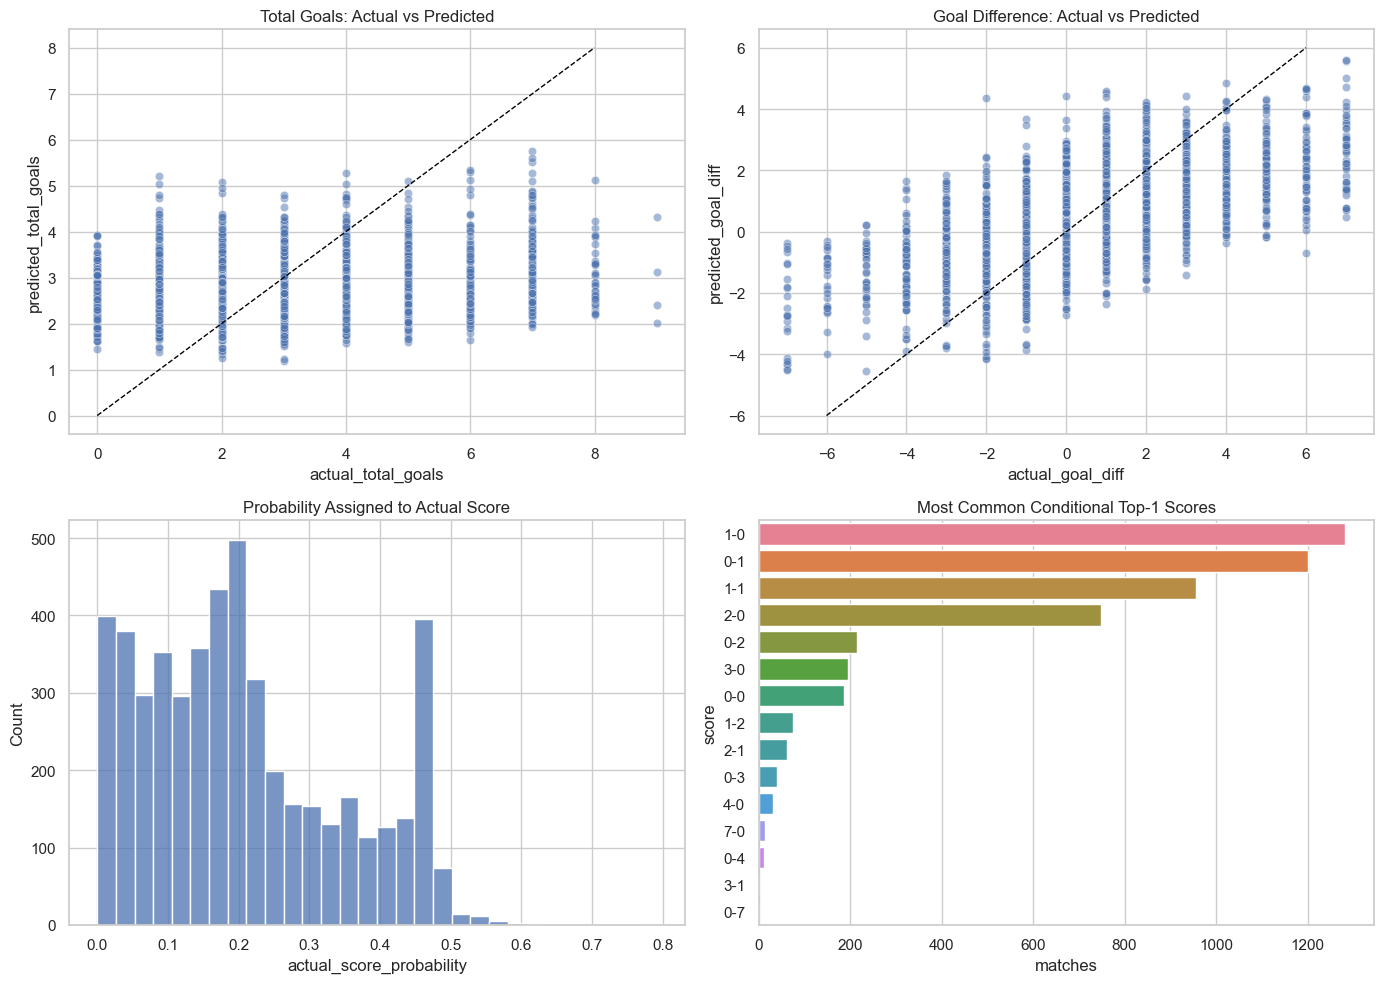

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=df_validation,
    x='actual_total_goals',
    y='predicted_total_goals',
    alpha=0.5,
    ax=axes[0, 0],
)
axes[0, 0].plot([0, 8], [0, 8], color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Total Goals: Actual vs Predicted')

sns.scatterplot(
    data=df_validation,
    x='actual_goal_diff',
    y='predicted_goal_diff',
    alpha=0.5,
    ax=axes[0, 1],
)
axes[0, 1].plot([-6, 6], [-6, 6], color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('Goal Difference: Actual vs Predicted')

sns.histplot(
    data=df_validation,
    x='actual_score_probability',
    bins=30,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Probability Assigned to Actual Score')

top_scores = (
    df_validation['conditional_top_score']
    .value_counts()
    .head(15)
    .rename_axis('score')
    .reset_index(name='matches')
)
sns.barplot(data=top_scores, x='matches', y='score', hue='score', dodge=False, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Most Common Conditional Top-1 Scores')

plt.tight_layout()
plt.show()

In [6]:
worst_total_goal_misses = df_validation.sort_values('total_goal_error', ascending=False).head(20)
worst_goal_diff_misses = df_validation.sort_values('goal_diff_error', ascending=False).head(20)
least_likely_actual_scores = df_validation.sort_values('actual_score_probability').head(20)

print('Worst total-goal misses')
display(worst_total_goal_misses[[
    'date', 'team_a', 'team_b', 'actual_goals_a', 'actual_goals_b',
    'predicted_expected_goals_a', 'predicted_expected_goals_b', 'total_goal_error',
    'conditional_top_score', 'actual_score_probability'
]])

print('Worst goal-difference misses')
display(worst_goal_diff_misses[[
    'date', 'team_a', 'team_b', 'actual_goals_a', 'actual_goals_b',
    'predicted_expected_goals_a', 'predicted_expected_goals_b', 'goal_diff_error',
    'conditional_top_score', 'actual_score_probability'
]])

print('Actual scores the model assigned the lowest conditional probability')
display(least_likely_actual_scores[[
    'date', 'team_a', 'team_b', 'actual_goals_a', 'actual_goals_b',
    'conditional_top_score', 'conditional_top_score_probability', 'actual_score_probability'
]])

Worst total-goal misses


,date,team_a,team_b,actual_goals_a,actual_goals_b,predicted_expected_goals_a,predicted_expected_goals_b,total_goal_error,conditional_top_score,actual_score_probability
4715,2025-09-09,Venezuela,Colombia,3,6,1.072036,0.950643,6.977322,0-1,0.000088
4520,2025-06-05,Spain,France,5,4,1.209662,1.189313,6.601025,1-0,0.000446
4682,2025-09-08,Israel,Italy,4,5,0.539738,2.580173,5.880089,0-2,0.000183
2373,2022-03-24,New Zealand,New Caledonia,7,1,1.207888,0.983862,5.808249,1-0,0.000233
3161,2023-09-08,Georgia,Spain,1,7,0.593379,1.612870,5.793751,0-1,0.000736
2595,2022-06-11,Guyana,Haiti,2,6,0.948524,1.292162,5.759314,0-1,0.000697
1099,2019-11-18,Niger,Madagascar,2,6,1.181389,1.121618,5.696994,0-1,0.000561
1708,2021-06-28,Croatia,Spain,3,5,1.021245,1.359577,5.619178,0-1,0.001427
2086,2021-11-11,Malta,Croatia,1,7,1.062411,1.361310,5.576278,0-1,0.000445
346,2018-11-17,Seychelles,Libya,1,7,0.799463,1.650431,5.550106,0-1,0.000992


Worst goal-difference misses


,date,team_a,team_b,actual_goals_a,actual_goals_b,predicted_expected_goals_a,predicted_expected_goals_b,goal_diff_error,conditional_top_score,actual_score_probability
1718,2021-07-02,Bermuda,Barbados,7,1,1.057166,1.750337,6.693171,1-0,0.000156
240,2018-10-13,Turks and Caicos Islands,Guyana,0,7,1.377596,1.761877,6.615718,1-2,0.001236
4420,2025-03-21,Belize,Costa Rica,0,7,0.942592,1.408751,6.533841,0-1,0.000526
3434,2023-11-20,Samoa,American Samoa,7,0,2.036341,1.544399,6.508058,2-1,0.002163
4668,2025-09-07,Fiji,Hong Kong,0,7,1.052833,1.615427,6.437407,0-1,0.000975
2981,2023-06-14,Mauritius,Djibouti,1,3,4.597229,0.227688,6.369540,0-1,0.022141
3497,2023-11-24,Cook Islands,New Caledonia,0,7,0.957571,1.629927,6.327644,0-1,0.001071
3676,2024-03-26,Syria,Myanmar,7,0,1.532841,0.812174,6.279333,1-0,0.000856
2647,2022-06-14,Indonesia,Nepal,7,0,1.733978,0.985835,6.251858,1-0,0.001421
3917,2024-09-05,Japan,China PR,7,0,1.480123,0.695325,6.215202,1-0,0.000763


Actual scores the model assigned the lowest conditional probability


,date,team_a,team_b,actual_goals_a,actual_goals_b,conditional_top_score,conditional_top_score_probability,actual_score_probability
4151,2024-10-14,Aruba,Haiti,3,5,0-3,0.228597,2.106825e-26
1490,2021-03-28,Cuba,Curaçao,1,2,0-3,0.215375,1.760557e-09
3345,2023-11-16,Cyprus,Spain,1,3,0-4,0.197818,1.900876e-09
3388,2023-11-17,Kazakhstan,San Marino,3,1,4-0,0.198192,1.921608e-09
3754,2024-06-09,Barbados,Haiti,1,3,0-3,0.202640,2.026403e-09
1052,2019-11-16,San Marino,Kazakhstan,1,3,0-3,0.211652,2.116518e-09
1477,2021-03-28,Ghana,São Tomé and Príncipe,3,1,3-0,0.223376,2.233758e-09
4715,2025-09-09,Venezuela,Colombia,3,6,0-1,0.398560,8.825187e-05
1718,2021-07-02,Bermuda,Barbados,7,1,1-0,0.279607,1.558116e-04
4682,2025-09-08,Israel,Italy,4,5,0-2,0.180873,1.831006e-04
